In [1]:
# Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess


In [2]:
# Load and preprocess data
DATA_DIR = 'sign_language_data'
IMG_SIZE = 64
categories = sorted(os.listdir(DATA_DIR))
label_map = {label: idx for idx, label in enumerate(categories)}
X, y = [], []
for label in categories:
    path = os.path.join(DATA_DIR, label)
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        y.append(label_map[label])
X = np.array(X)
y = to_categorical(y, num_classes=len(categories))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
# Build models
def build_simple_cnn(filters=32, dense_units=128):
    model = Sequential([
        Conv2D(filters, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(dense_units, activation='relu'),
        Dense(len(categories), activation='softmax')
    ])
    return model


In [4]:
def build_deep_cnn(filters1=64, filters2=128, dense_units=256):
    model = Sequential([
        Conv2D(filters1, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        MaxPooling2D(2, 2),
        Conv2D(filters2, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dropout(0.5),
        Dense(dense_units, activation='relu'),
        Dense(len(categories), activation='softmax')
    ])
    return model


In [5]:
def build_mobilenet(trainable=False, dense_units=128):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = trainable
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(dense_units, activation='relu')(x)
    output = Dense(len(categories), activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model


In [6]:
def build_efficientnet(trainable=False, dense_units=128):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = trainable
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(dense_units, activation='relu')(x)
    output = Dense(len(categories), activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model


In [7]:
# Train function
def train_and_evaluate(model, name, preprocess_fn=None, epochs=10):
    print(f"Training: {name}")
    X_train_proc = preprocess_fn(X_train) if preprocess_fn else X_train / 255.0
    X_test_proc = preprocess_fn(X_test) if preprocess_fn else X_test / 255.0

    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train_proc, y_train, validation_data=(X_test_proc, y_test), epochs=epochs, verbose=2)
    preds = model.predict(X_test_proc)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_test, axis=1)
    acc = accuracy_score(y_true, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=categories))
    return acc

# Hyperparameter search for each model
results = {}

In [8]:
# SimpleCNN tuning
best_acc = 0
for filters in [32, 64]:
    for dense_units in [64, 128]:
        model = build_simple_cnn(filters=filters, dense_units=dense_units)
        name = f"SimpleCNN_f{filters}_d{dense_units}"
        acc = train_and_evaluate(model, name)
        results[name] = acc
        best_acc = max(best_acc, acc)


C:\Users\vamsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training: SimpleCNN_f32_d64
Epoch 1/10
141/141 - 13s - 89ms/step - accuracy: 0.0790 - loss: 3.1882 - val_accuracy: 0.0981 - val_loss: 2.8634
Epoch 2/10
141/141 - 8s - 56ms/step - accuracy: 0.1640 - loss: 2.5815 - val_accuracy: 0.2239 - val_loss: 2.3594
Epoch 3/10
141/141 - 9s - 62ms/step - accuracy: 0.2642 - loss: 2.1859 - val_accuracy: 0.3202 - val_loss: 2.0966
Epoch 4/10
141/141 - 9s - 63ms/step - accuracy: 0.5192 - loss: 1.5018 - val_accuracy: 0.7574 - val_loss: 0.9223
Epoch 5/10
141/141 - 10s - 68ms/step - accuracy: 0.8445 - loss: 0.6399 - val_accuracy: 0.8849 - val_loss: 0.4826
Epoch 6/10
141/141 - 11s - 77ms/step - accuracy: 0.9259 - loss: 0.3513 - val_accuracy: 0.9206 - val_loss: 0.3658
Epoch 7/10
141/141 - 8s - 57ms/step - accuracy: 0.9507 - loss: 0.2363 - val_accuracy: 0.9367 - val_loss: 0.3090
Epoch 8/10
141/141 - 8s - 60ms/step - accuracy: 0.9708 - loss: 0.1714 - val_accuracy: 0.9429 - val_loss: 0.2639
Epoch 9/10
141/141 - 10s - 68ms/step - accuracy: 0.9808 - loss: 0.1208 - 

C:\Users\vamsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training: SimpleCNN_f32_d128
Epoch 1/10
141/141 - 17s - 122ms/step - accuracy: 0.5674 - loss: 1.9606 - val_accuracy: 0.9117 - val_loss: 0.5435
Epoch 2/10
141/141 - 11s - 78ms/step - accuracy: 0.9420 - loss: 0.3159 - val_accuracy: 0.9723 - val_loss: 0.1880
Epoch 3/10
141/141 - 11s - 78ms/step - accuracy: 0.9830 - loss: 0.1186 - val_accuracy: 0.9732 - val_loss: 0.1385
Epoch 4/10
141/141 - 11s - 78ms/step - accuracy: 0.9951 - loss: 0.0519 - val_accuracy: 0.9795 - val_loss: 0.1066
Epoch 5/10
141/141 - 11s - 78ms/step - accuracy: 0.9987 - loss: 0.0257 - val_accuracy: 0.9857 - val_loss: 0.0920
Epoch 6/10
141/141 - 11s - 80ms/step - accuracy: 0.9993 - loss: 0.0135 - val_accuracy: 0.9893 - val_loss: 0.0737
Epoch 7/10
141/141 - 11s - 77ms/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 0.9893 - val_loss: 0.0660
Epoch 8/10
141/141 - 11s - 75ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.9875 - val_loss: 0.0697
Epoch 9/10
141/141 - 11s - 77ms/step - accuracy: 1.0000 - loss: 0.

C:\Users\vamsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
141/141 - 18s - 128ms/step - accuracy: 0.2095 - loss: 2.8343 - val_accuracy: 0.4211 - val_loss: 1.8478
Epoch 2/10
141/141 - 14s - 96ms/step - accuracy: 0.7285 - loss: 1.0509 - val_accuracy: 0.8314 - val_loss: 0.6603
Epoch 3/10
141/141 - 15s - 105ms/step - accuracy: 0.8934 - loss: 0.4639 - val_accuracy: 0.9028 - val_loss: 0.3936
Epoch 4/10
141/141 - 24s - 172ms/step - accuracy: 0.9344 - loss: 0.2820 - val_accuracy: 0.9260 - val_loss: 0.2880
Epoch 5/10
141/141 - 19s - 131ms/step - accuracy: 0.9683 - loss: 0.1499 - val_accuracy: 0.9402 - val_loss: 0.2452
Epoch 6/10
141/141 - 19s - 137ms/step - accuracy: 0.9797 - loss: 0.1130 - val_accuracy: 0.9393 - val_loss: 0.2237
Epoch 7/10
141/141 - 22s - 153ms/step - accuracy: 0.9877 - loss: 0.0707 - val_accuracy: 0.9643 - val_loss: 0.1767
Epoch 8/10
141/141 - 18s - 130ms/step - accuracy: 0.9960 - loss: 0.0425 - val_accuracy: 0.9670 - val_loss: 0.1622
Epoch 9/10
141/141 - 17s - 119ms/step - accuracy: 0.9969 - loss: 0.0306 - val_accuracy: 0

C:\Users\vamsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training: SimpleCNN_f64_d128
Epoch 1/10
141/141 - 28s - 201ms/step - accuracy: 0.6129 - loss: 1.7923 - val_accuracy: 0.9509 - val_loss: 0.2954
Epoch 2/10
141/141 - 26s - 187ms/step - accuracy: 0.9688 - loss: 0.1636 - val_accuracy: 0.9759 - val_loss: 0.1245
Epoch 3/10
141/141 - 23s - 164ms/step - accuracy: 0.9931 - loss: 0.0500 - val_accuracy: 0.9884 - val_loss: 0.0817
Epoch 4/10
141/141 - 23s - 160ms/step - accuracy: 0.9991 - loss: 0.0174 - val_accuracy: 0.9893 - val_loss: 0.0710
Epoch 5/10
141/141 - 41s - 288ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 0.9893 - val_loss: 0.0578
Epoch 6/10
141/141 - 22s - 155ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.9929 - val_loss: 0.0534
Epoch 7/10
141/141 - 22s - 158ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.9902 - val_loss: 0.0561
Epoch 8/10
141/141 - 23s - 161ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9911 - val_loss: 0.0534
Epoch 9/10
141/141 - 22s - 157ms/step - accuracy: 1.0000 - 

In [9]:
# DeepCNN tuning
for f1 in [32, 64]:
    for f2 in [64, 128]:
        for dense in [128, 256]:
            model = build_deep_cnn(filters1=f1, filters2=f2, dense_units=dense)
            name = f"DeepCNN_f1{f1}_f2{f2}_d{dense}"
            acc = train_and_evaluate(model, name)
            results[name] = acc


C:\Users\vamsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training: DeepCNN_f132_f264_d128
Epoch 1/10
141/141 - 19s - 138ms/step - accuracy: 0.6406 - loss: 1.3434 - val_accuracy: 0.9741 - val_loss: 0.1685
Epoch 2/10
141/141 - 15s - 104ms/step - accuracy: 0.9554 - loss: 0.1815 - val_accuracy: 0.9616 - val_loss: 0.1299
Epoch 3/10
141/141 - 16s - 111ms/step - accuracy: 0.9748 - loss: 0.1003 - val_accuracy: 0.9804 - val_loss: 0.0792
Epoch 4/10
141/141 - 16s - 114ms/step - accuracy: 0.9846 - loss: 0.0555 - val_accuracy: 0.9822 - val_loss: 0.0826
Epoch 5/10
141/141 - 16s - 110ms/step - accuracy: 0.9902 - loss: 0.0403 - val_accuracy: 0.9920 - val_loss: 0.0523
Epoch 6/10
141/141 - 16s - 112ms/step - accuracy: 0.9953 - loss: 0.0169 - val_accuracy: 0.9893 - val_loss: 0.0465
Epoch 7/10
141/141 - 22s - 154ms/step - accuracy: 0.9924 - loss: 0.0255 - val_accuracy: 0.9893 - val_loss: 0.0790
Epoch 8/10
141/141 - 22s - 157ms/step - accuracy: 0.9964 - loss: 0.0142 - val_accuracy: 0.9866 - val_loss: 0.0738
Epoch 9/10
141/141 - 16s - 116ms/step - accuracy: 0.991

C:\Users\vamsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training: DeepCNN_f132_f264_d256
Epoch 1/10
141/141 - 25s - 176ms/step - accuracy: 0.6975 - loss: 1.1479 - val_accuracy: 0.9581 - val_loss: 0.2240
Epoch 2/10
141/141 - 21s - 148ms/step - accuracy: 0.9589 - loss: 0.1746 - val_accuracy: 0.9741 - val_loss: 0.1194
Epoch 3/10
141/141 - 17s - 123ms/step - accuracy: 0.9797 - loss: 0.0888 - val_accuracy: 0.9822 - val_loss: 0.0810
Epoch 4/10
141/141 - 17s - 117ms/step - accuracy: 0.9857 - loss: 0.0486 - val_accuracy: 0.9884 - val_loss: 0.0712
Epoch 5/10
141/141 - 17s - 120ms/step - accuracy: 0.9931 - loss: 0.0312 - val_accuracy: 0.9902 - val_loss: 0.0664
Epoch 6/10
141/141 - 18s - 126ms/step - accuracy: 0.9900 - loss: 0.0344 - val_accuracy: 0.9804 - val_loss: 0.1403
Epoch 7/10
141/141 - 17s - 120ms/step - accuracy: 0.9933 - loss: 0.0263 - val_accuracy: 0.9938 - val_loss: 0.0712
Epoch 8/10
141/141 - 17s - 124ms/step - accuracy: 0.9942 - loss: 0.0241 - val_accuracy: 0.9902 - val_loss: 0.0734
Epoch 9/10
141/141 - 16s - 115ms/step - accuracy: 0.996

C:\Users\vamsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Training: DeepCNN_f164_f264_d256
Epoch 1/10
141/141 - 34s - 242ms/step - accuracy: 0.5692 - loss: 1.6096 - val_accuracy: 0.9474 - val_loss: 0.2230
Epoch 2/10
141/141 - 30s - 212ms/step - accuracy: 0.9418 - loss: 0.2215 - val_accuracy: 0.9670 - val_loss: 0.1735
Epoch 3/10
141/141 - 33s - 235ms/step - accuracy: 0.9688 - loss: 0.1213 - val_accuracy: 0.9839 - val_loss: 0.0781
Epoch 4/10
141/141 - 30s - 210ms/step - accuracy: 0.9844 - loss: 0.0655 - val_accuracy: 0.9893 - val_loss: 0.0493
Epoch 5/10
141/141 - 30s - 215ms/step - accuracy: 0.9880 - loss: 0.0431 - val_accuracy: 0.9786 - val_loss: 0.1104
Epoch 6/10
141/141 - 28s - 196ms/step - accuracy: 0.9866 - loss: 0.0543 - val_accuracy: 0.9884 - val_loss: 0.0694
Epoch 7/10
141/141 - 29s - 205ms/step - accuracy: 0.9893 - loss: 0.0387 - val_accuracy: 0.9893 - val_loss: 0.0642
Epoch 8/10
141/141 - 29s - 203ms/step - accuracy: 0.9931 - loss: 0.0226 - val_accuracy: 0.9946 - val_loss: 0.0455
Epoch 9/10
141/141 - 29s - 209ms/step - accuracy: 0.996

C:\Users\vamsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training: DeepCNN_f164_f2128_d128
Epoch 1/10
141/141 - 49s - 349ms/step - accuracy: 0.6243 - loss: 1.4086 - val_accuracy: 0.9411 - val_loss: 0.2578
Epoch 2/10
141/141 - 44s - 312ms/step - accuracy: 0.9482 - loss: 0.2155 - val_accuracy: 0.9759 - val_loss: 0.1144
Epoch 3/10
141/141 - 42s - 299ms/step - accuracy: 0.9737 - loss: 0.1036 - val_accuracy: 0.9831 - val_loss: 0.0835
Epoch 4/10
141/141 - 42s - 299ms/step - accuracy: 0.9824 - loss: 0.0653 - val_accuracy: 0.9857 - val_loss: 0.0867
Epoch 5/10
141/141 - 42s - 300ms/step - accuracy: 0.9866 - loss: 0.0464 - val_accuracy: 0.9911 - val_loss: 0.0649
Epoch 6/10
141/141 - 46s - 328ms/step - accuracy: 0.9897 - loss: 0.0347 - val_accuracy: 0.9902 - val_loss: 0.0749
Epoch 7/10
141/141 - 42s - 296ms/step - accuracy: 0.9922 - loss: 0.0362 - val_accuracy: 0.9831 - val_loss: 0.0817
Epoch 8/10
141/141 - 42s - 299ms/step - accuracy: 0.9940 - loss: 0.0302 - val_accuracy: 0.9884 - val_loss: 0.0841
Epoch 9/10
141/141 - 42s - 301ms/step - accuracy: 0.99

C:\Users\vamsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
141/141 - 47s - 333ms/step - accuracy: 0.6129 - loss: 1.4432 - val_accuracy: 0.9483 - val_loss: 0.2259
Epoch 2/10
141/141 - 45s - 317ms/step - accuracy: 0.9433 - loss: 0.2472 - val_accuracy: 0.9679 - val_loss: 0.1883
Epoch 3/10
141/141 - 47s - 334ms/step - accuracy: 0.9652 - loss: 0.1440 - val_accuracy: 0.9804 - val_loss: 0.0916
Epoch 4/10
141/141 - 47s - 336ms/step - accuracy: 0.9777 - loss: 0.0789 - val_accuracy: 0.9875 - val_loss: 0.0558
Epoch 5/10
141/141 - 50s - 353ms/step - accuracy: 0.9817 - loss: 0.0606 - val_accuracy: 0.9929 - val_loss: 0.0458
Epoch 6/10
141/141 - 79s - 559ms/step - accuracy: 0.9891 - loss: 0.0437 - val_accuracy: 0.9768 - val_loss: 0.1118
Epoch 7/10
141/141 - 73s - 517ms/step - accuracy: 0.9815 - loss: 0.0667 - val_accuracy: 0.9911 - val_loss: 0.0599
Epoch 8/10
141/141 - 53s - 379ms/step - accuracy: 0.9906 - loss: 0.0358 - val_accuracy: 0.9938 - val_loss: 0.0658
Epoch 9/10
141/141 - 52s - 371ms/step - accuracy: 0.9931 - loss: 0.0259 - val_accuracy: 

In [10]:
# MobileNetV2 tuning
for dense in [64, 128, 256]:
    model = build_mobilenet(trainable=False, dense_units=dense)
    name = f"MobileNetV2_d{dense}"
    acc = train_and_evaluate(model, name, preprocess_fn=mobilenet_preprocess)
    results[name] = acc

C:\Users\vamsi\AppData\Local\Temp\ipykernel_27300\4073702181.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training: MobileNetV2_d64
Epoch 1/10
141/141 - 48s - 339ms/step - accuracy: 0.6154 - loss: 1.4765 - val_accuracy: 0.8385 - val_loss: 0.5915
Epoch 2/10
141/141 - 27s - 193ms/step - accuracy: 0.8951 - loss: 0.4228 - val_accuracy: 0.8885 - val_loss: 0.3689
Epoch 3/10
141/141 - 26s - 184ms/step - accuracy: 0.9520 - loss: 0.2247 - val_accuracy: 0.9331 - val_loss: 0.2623
Epoch 4/10
141/141 - 26s - 186ms/step - accuracy: 0.9732 - loss: 0.1434 - val_accuracy: 0.9340 - val_loss: 0.2438
Epoch 5/10
141/141 - 25s - 178ms/step - accuracy: 0.9839 - loss: 0.0973 - val_accuracy: 0.9438 - val_loss: 0.2132
Epoch 6/10
141/141 - 29s - 203ms/step - accuracy: 0.9909 - loss: 0.0691 - val_accuracy: 0.9429 - val_loss: 0.2013
Epoch 7/10
141/141 - 26s - 183ms/step - accuracy: 0.9962 - loss: 0.0490 - val_accuracy: 0.9492 - val_loss: 0.1825
Epoch 8/10
141/141 - 26s - 182ms/step - accuracy: 0.9978 - loss: 0.0371 - val_accuracy: 0.9447 - val_loss: 0.1905
Epoch 9/10
14

C:\Users\vamsi\AppData\Local\Temp\ipykernel_27300\4073702181.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))


Training: MobileNetV2_d128
Epoch 1/10
141/141 - 42s - 299ms/step - accuracy: 0.6751 - loss: 1.2151 - val_accuracy: 0.8751 - val_loss: 0.4726
Epoch 2/10
141/141 - 26s - 183ms/step - accuracy: 0.9174 - loss: 0.3198 - val_accuracy: 0.9081 - val_loss: 0.3224
Epoch 3/10
141/141 - 24s - 169ms/step - accuracy: 0.9614 - loss: 0.1678 - val_accuracy: 0.9340 - val_loss: 0.2422
Epoch 4/10
141/141 - 25s - 176ms/step - accuracy: 0.9806 - loss: 0.1020 - val_accuracy: 0.9456 - val_loss: 0.2055
Epoch 5/10
141/141 - 24s - 167ms/step - accuracy: 0.9915 - loss: 0.0624 - val_accuracy: 0.9509 - val_loss: 0.1949
Epoch 6/10
141/141 - 24s - 172ms/step - accuracy: 0.9960 - loss: 0.0417 - val_accuracy: 0.9420 - val_loss: 0.2071
Epoch 7/10
141/141 - 25s - 175ms/step - accuracy: 0.9946 - loss: 0.0397 - val_accuracy: 0.9599 - val_loss: 0.1631
Epoch 8/10
141/141 - 24s - 167ms/step - accuracy: 0.9984 - loss: 0.0224 - val_accuracy: 0.9554 - val_loss: 0.1657
Epoch 9/10
141/141 - 25s - 179ms/step - accuracy: 1.0000 - lo

C:\Users\vamsi\AppData\Local\Temp\ipykernel_27300\4073702181.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))


Training: MobileNetV2_d256
Epoch 1/10
141/141 - 42s - 299ms/step - accuracy: 0.7390 - loss: 0.9831 - val_accuracy: 0.8831 - val_loss: 0.3961
Epoch 2/10
141/141 - 27s - 193ms/step - accuracy: 0.9313 - loss: 0.2645 - val_accuracy: 0.9322 - val_loss: 0.2447
Epoch 3/10
141/141 - 27s - 191ms/step - accuracy: 0.9746 - loss: 0.1156 - val_accuracy: 0.9367 - val_loss: 0.2353
Epoch 4/10
141/141 - 25s - 175ms/step - accuracy: 0.9864 - loss: 0.0673 - val_accuracy: 0.9527 - val_loss: 0.1782
Epoch 5/10
141/141 - 25s - 180ms/step - accuracy: 0.9960 - loss: 0.0368 - val_accuracy: 0.9438 - val_loss: 0.1890
Epoch 6/10
141/141 - 26s - 181ms/step - accuracy: 0.9969 - loss: 0.0258 - val_accuracy: 0.9563 - val_loss: 0.1640
Epoch 7/10
141/141 - 27s - 188ms/step - accuracy: 0.9973 - loss: 0.0193 - val_accuracy: 0.9599 - val_loss: 0.1574
Epoch 8/10
141/141 - 25s - 181ms/step - accuracy: 0.9993 - loss: 0.0113 - val_accuracy: 0.9625 - val_loss: 0.1583
Epoch 9/10
141/141 - 26s - 184ms/step - accuracy: 1.0000 - lo

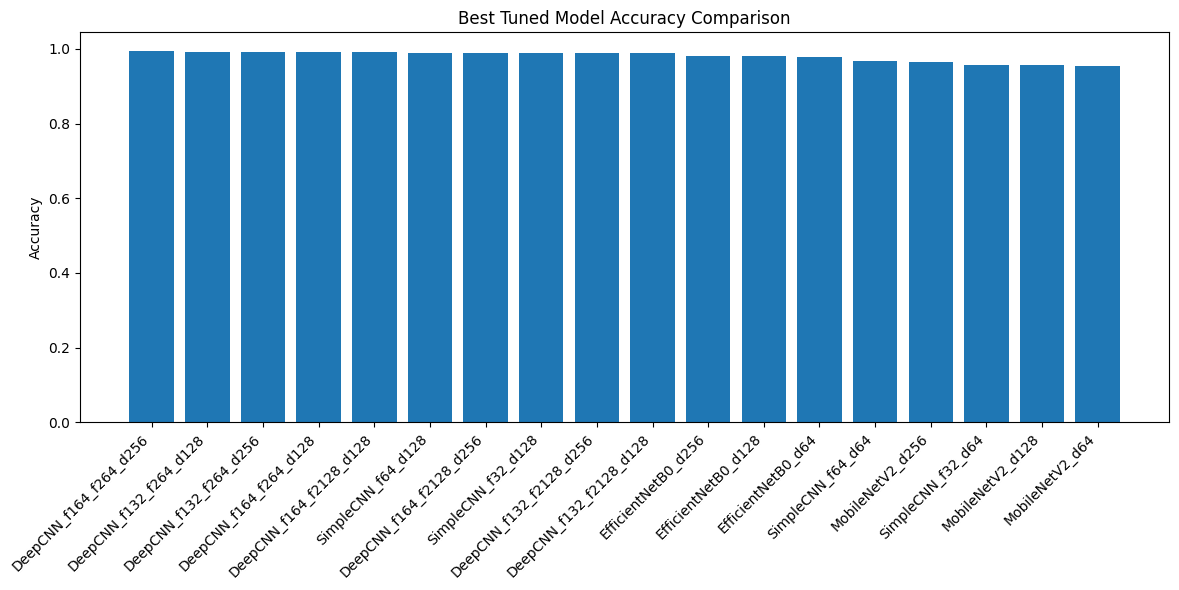

In [12]:
# Plot
sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
plt.figure(figsize=(12, 6))
plt.bar(sorted_results.keys(), sorted_results.values())
plt.title("Best Tuned Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
def plot_training(history, name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} Loss')
    plt.legend()

    plt.show()


In [16]:
import pandas as pd

# Convert the results dict {model_name: accuracy} to a list of tuples
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("\nModel Performance Summary:")
print(results_df.to_string(index=False))



Model Performance Summary:
                  Model  Accuracy
 DeepCNN_f164_f264_d256  0.994648
 DeepCNN_f132_f264_d128  0.992864
 DeepCNN_f132_f264_d256  0.992864
 DeepCNN_f164_f264_d128  0.992864
DeepCNN_f164_f2128_d128  0.991079
DeepCNN_f164_f2128_d256  0.990187
     SimpleCNN_f64_d128  0.990187
DeepCNN_f132_f2128_d256  0.989295
     SimpleCNN_f32_d128  0.989295
DeepCNN_f132_f2128_d128  0.988403
    EfficientNetB0_d256  0.982159
    EfficientNetB0_d128  0.980375
     EfficientNetB0_d64  0.979483
      SimpleCNN_f64_d64  0.968778
       MobileNetV2_d256  0.966102
       MobileNetV2_d128  0.958073
      SimpleCNN_f32_d64  0.958073
        MobileNetV2_d64  0.954505


In [17]:
# Group by model type prefix
results_df["BaseModel"] = results_df["Model"].str.extract(r'^(SimpleCNN|DeepCNN|MobileNetV2|EfficientNetB0)')
best_per_model = results_df.loc[results_df.groupby("BaseModel")["Accuracy"].idxmax()]

print("Best Accuracy Per Model Type:")
print(best_per_model.sort_values("Accuracy", ascending=False).to_string(index=False))


Best Accuracy Per Model Type:
                 Model  Accuracy      BaseModel
DeepCNN_f164_f264_d256  0.994648        DeepCNN
    SimpleCNN_f64_d128  0.990187      SimpleCNN
   EfficientNetB0_d256  0.982159 EfficientNetB0
      MobileNetV2_d256  0.966102    MobileNetV2


In [18]:
# Rebuild the best model (DeepCNN_f164_f264_d256)
def build_best_deepcnn():
    model = Sequential([
        Conv2D(64, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),  # f1 = 64
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),  # f2 = 64
        MaxPooling2D(2, 2),
        Flatten(),
        Dropout(0.5),
        Dense(256, activation='relu'),  # dense = 256
        Dense(len(categories), activation='softmax')
    ])
    return model


In [19]:
def train_and_evaluate(model, name, preprocess_fn=None, epochs=10):
    print(f"Training: {name}")
    X_train_proc = preprocess_fn(X_train) if preprocess_fn else X_train / 255.0
    X_test_proc = preprocess_fn(X_test) if preprocess_fn else X_test / 255.0

    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train_proc, y_train, validation_data=(X_test_proc, y_test), epochs=epochs, verbose=2)

    # Save the model
    model.save(f"{name}.h5")

    preds = model.predict(X_test_proc)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_test, axis=1)
    acc = accuracy_score(y_true, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=categories))
    return acc


In [20]:
model = build_best_deepcnn()
train_and_evaluate(model, "DeepCNN_f164_f264_d256", epochs=10)

C:\Users\vamsi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training: DeepCNN_f164_f264_d256
Epoch 1/10
141/141 - 40s - 280ms/step - accuracy: 0.6809 - loss: 1.1964 - val_accuracy: 0.9509 - val_loss: 0.2236
Epoch 2/10
141/141 - 34s - 238ms/step - accuracy: 0.9565 - loss: 0.1787 - val_accuracy: 0.9813 - val_loss: 0.0884
Epoch 3/10
141/141 - 34s - 244ms/step - accuracy: 0.9743 - loss: 0.1071 - val_accuracy: 0.9831 - val_loss: 0.0667
Epoch 4/10
141/141 - 30s - 210ms/step - accuracy: 0.9835 - loss: 0.0631 - val_accuracy: 0.9857 - val_loss: 0.0825
Epoch 5/10
141/141 - 36s - 259ms/step - accuracy: 0.9924 - loss: 0.0314 - val_accuracy: 0.9839 - val_loss: 0.0818
Epoch 6/10
141/141 - 31s - 220ms/step - accuracy: 0.9940 - loss: 0.0189 - val_accuracy: 0.9929 - val_loss: 0.0501
Epoch 7/10
141/141 - 41s - 292ms/step - accuracy: 0.9938 - loss: 0.0247 - val_accuracy: 0.9884 - val_loss: 0.0691
Epoch 8/10
141/141 - 32s - 224ms/step - accuracy: 0.9958 - loss: 0.0209 - val_accuracy: 0.9902 - val_loss: 0.0660
Epoch 9/10
141/141 - 36s - 254ms/step - accuracy: 0.993

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
DeepCNN_f164_f264_d256 Accuracy: 0.9946
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        46
           B       0.98      1.00      0.99        48
           C       1.00      0.96      0.98        46
           D       1.00      1.00      1.00        42
           E       1.00      1.00      1.00        37
           F       1.00      1.00      1.00        47
           G       1.00      1.00      1.00        35
           H       1.00      1.00      1.00        43
           I       1.00      1.00      1.00        35
           J       1.00      1.00      1.00        41
           K       1.00      1.00      1.00        36
           L       1.00      1.00      1.00        43
           M       1.00      1.00      1.00        47
           N       1.00      0.97      0.99        40
           O       0.97      1.00      0.99        34
           P       1.00      0.95      0.97        39
 

0.9946476360392507

In [21]:
import json

with open("label_map.json", "w") as f:
    json.dump(label_map, f)


In [22]:
with open("label.txt", "w") as f:
    json.dump(label_map, f)
